In [ ]:
import os, sys

# Colab: Drive をマウントしてプロジェクトを配置した場所へ
from google.colab import drive
drive.mount('/content/drive')
PROJECT_ROOT = '/content/drive/MyDrive/ColabProject/deep-learning-6'

os.chdir(PROJECT_ROOT)
sys.path.append(PROJECT_ROOT)

Mounted at /content/drive


In [ ]:
from itertools import cycle
import re
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from codebot.model import GPT
from codebot.tokenizer import BPETokenizer
from codebot.utils import generate, get_device

### dataset

In [ ]:
class GRPODataset(Dataset):
    def __init__(self, tokenzier):
        self.tokenizer = tokenzier
        self.data = []
        for i in range(1,10):
            for j in range(1,10):
                prompt = f"### Instruction:\n{i}+{j}=\n\n### Response:\n"
                ground_truth = i + j
                self.data.append((prompt, ground_truth))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    # バッチデータの作成
    def get_batch(self, prompts, responses, device):
        """promptsは0, responsesは1でマスキング、不要な箇所は0でpadding"""
        all_ids = []
        all_masks = []

        for prompt, response in zip(prompts, responses):
            prompt_ids = self.tokenizer.encode(prompt)
            response_ids = self.tokenizer.encode(response)

            ids = prompt_ids + response_ids
            mask = [0] * len(prompt_ids) + [1] * len(response_ids)  # promptsは0, responsesは1

            all_ids.append(ids)
            all_masks.append(mask)

        # padding
        max_len = max(len(ids) for ids in all_ids)
        padded_ids = []
        padded_masks = []
        for ids, mask in zip(all_ids, all_masks):
            pad_len = max_len - len(ids)
            padded_ids.append(ids + [0] * pad_len)
            padded_masks.append(mask + [0] * pad_len)

        ids = torch.tensor(padded_ids, dtype=torch.long, device=device)
        mask = torch.tensor(padded_masks, dtype=torch.float, device=device)

        return ids, mask

### 報酬関数

In [ ]:
def calculate_reward(ground_truth, response):
    """正解値と比較してあっていれば1"""
    try:
        matches = re.findall(r"(-?\d+)", response)  # マイナス記号が0 or 1個、一桁以上の数字
        if matches:
            predicted = int(matches[-1])
            return 1.0 if predicted == ground_truth else 0.0
        return 0.0
    except:
        return 0.0

### グループ生成

In [ ]:
def generate_group(model, tokenizer, prompts, gts, group_size):
    """1つのプロンプトに対して、複数の回答(group)を生成しそれぞれのアドバンテージを計算"""
    all_prompts = []
    all_responses = []
    all_advantages = []

    for prompt, gt in zip(prompts, gts):
        responses = []
        for _ in range(group_size):
            full_text = generate(model, tokenizer, prompt, temperature=1.0)
            response = full_text[len(prompt):]
            responses.append(response)

        reward = torch.tensor([calculate_reward(gt, r) for r in responses])
        advantages = reward - reward.mean()

        for response, advantage in zip(responses, advantages):
            all_prompts.append(prompt)
            all_responses.append(response)
            all_advantages.append(advantage)

    return all_prompts, all_responses, torch.stack(all_advantages)

### 損失関数

#### 確率部分を計算

In [ ]:
def compute_probs(model, ids):
    logits = model(ids)  # (B,C,V)
    probs = F.softmax(logits[:,:-1,:], dim=-1)  # (B,C-1,V)
    labels = ids[:,1:]  # (B,C-1)

    token_probs = torch.gather(
        probs, dim=-1, index=labels.unsqueeze(-1)
    ).squeeze(-1)  # (B,C-1)

    return token_probs

#### GRPOの損失関数

$$
J_{\text{GRPO}}(\theta) = \mathbb{E}_{\tau \sim \pi_{\theta_{\text{old}}}} \left[ \sum_{t=0}^{T} \min\left( \frac{\pi_\theta(o_t \mid q, o_{<t})}{\pi_{\theta_{\text{old}}}(o_t \mid q, o_{<t})} A^{(i)}, \ \text{clip}\left( \frac{\pi_\theta(o_t \mid q, o_{<t})}{\pi_{\theta_{\text{old}}}(o_t \mid q, o_{<t})}, 1 - \varepsilon, 1 + \varepsilon \right) A^{(i)} \right) \right]
$$

コードに対応するのは下記である。
$$
\text{ratio} =
\frac{\pi_\theta(o_t \mid q, o_{<t})}{\pi_{\theta_{\text{old}}}(o_t \mid q, o_{<t})}
$$

$$
\text{advantage}=
A^{(i)}
$$

In [ ]:
def grpo_loss(model, old_model, ids, mask, advantages, epsilon=0.2):
    # 現在モデルの各トークンの確率
    probs = compute_probs(model, ids)
    # 古いモデルの各トークンの確率
    with torch.no_grad():
        old_probs = compute_probs(old_model, ids)

    # トークンごとの確率比
    ratio = probs / (old_probs + 1e-8)  # 0除算防止
    advantages = advantages.unsqueeze(-1)

    unclipped = ratio * advantages
    # torch.clamp:
    # テンソルのすべての要素を指定した範囲（最小値と最大値）内に収める（クリッピングする）関数
    clipped = torch.clamp(ratio, 1 - epsilon, 1 + epsilon) * advantages

    mask = mask[:, 1:]  # マスクもシフト
    token_objective = torch.min(unclipped, clipped) * mask

    # サンプル数(batch_size ✕ group_size)で正規化
    n_samples = ids.size(0)  # batch_size × group_size
    return -token_objective.sum() / n_samples


### setting

In [ ]:
# 設定
device = get_device()
tokenizer_path = 'codebot/merge_rules.pkl'
sft_model_path = 'codebot/model_sft.pt'
grpo_model_save_path = 'codebot/model_grpo.pt'

# ハイパーパラメータ
learning_rate = 7e-6
max_iters = 500
n_update_per_generation = 2  # 同じ生成データに対しての更新回数
eval_interval = 10
epsilon = 0.2  # クリッピング範囲
group_size = 8  # グループサイズ
batch_size = 32

# 初期化
tokenizer = BPETokenizer.load_from(tokenizer_path)
model = GPT.load_from(sft_model_path, device=device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

old_model = GPT.load_from(sft_model_path, device=device)  # 古いモデル
old_model.eval()

dataset = GRPODataset(tokenizer)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
data_iter = cycle(dataloader)

### 学習ループ

In [ ]:
accuracies = []
current_accuracy = 0.0
pbar = tqdm(range(max_iters))

for i in pbar:
    # バッチデータを取得
    prompts, gts = next(data_iter)

    # 古いモデル(old_model)を更新
    old_model.load_state_dict(model.state_dict())

    # 古いモデルで複数サンプルを生成し、報酬とアドバンテージを計算
    all_prompts, all_responses, all_advantages = generate_group(
        old_model, tokenizer, prompts, gts, group_size
    )

    # バッチデータの作成
    ids, mask = dataset.get_batch(all_prompts, all_responses, device)
    all_advantages = all_advantages.to(device)

    # 生成データに対して複数回更新
    for _ in range(n_update_per_generation):
        optimizer.zero_grad()
        loss = grpo_loss(model, old_model, ids, mask, all_advantages, epsilon)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # 勾配クリッピング
        optimizer.step()

    # 定期的に評価
    if i % eval_interval == 0:
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for prompt, gt in dataset.data:
                response = generate(model, tokenizer, prompt, temperature=0)
                reward = calculate_reward(gt, response)
                correct += reward > 0
                total += 1
        model.train()
        current_accuracy = correct / total * 100
        accuracies.append(current_accuracy)

    pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{current_accuracy:.1f}%'})

100%|██████████| 500/500 [52:18<00:00,  6.28s/it, loss=-0.0042, acc=87.7%]


### 学習済みモデルを保存 & 損失可視化

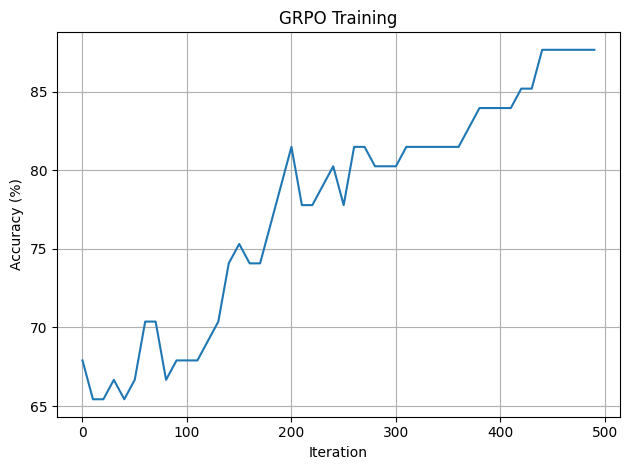

In [ ]:
model.save(grpo_model_save_path)

plt.figure()
steps = list(range(0, len(accuracies) * eval_interval, eval_interval))
plt.plot(steps, accuracies)
plt.xlabel('Iteration')
plt.ylabel('Accuracy (%)')
plt.title('GRPO Training')
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_grpo.png")